# DATA EXPLORATION - first group session

### Install packages

In [2]:
install.packages(c("vegan", "pastecs", "psych", "gplots", "fmsb"),
                 repos = "https://cloud.r-project.org")

Installation des packages dans 'C:/Users/victo/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)

installation des dépendances 'bitops', 'permute', 'mnormt', 'GPArotation', 'gtools', 'caTools'




le package 'bitops' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'permute' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'mnormt' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'GPArotation' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'gtools' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'caTools' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'vegan' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'pastecs' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'psych' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'gplots' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'fmsb' a été décompressé et les sommes MD5 ont été vérifiées avec succés

Les packages binaires téléchargés sont dans
	C:\U

### Functions

In [9]:
# coldiss()
# Color plots of a dissimilarity matrix, without and with ordering
#
# License: GPL-2
# Author:  Francois Gillet
#          23 August 2012 - rev. 07 June 2016

"coldiss" <- function(D,
                      nc = 4,
                      byrank = TRUE,
                      diag = FALSE) {
  require(gclus)
  
  D <- as.dist(as.matrix(D))
  
  if (max(D) > 1)
    D <- D / max(D)
  
  if (byrank) {
    spe.color <- dmat.color(1 - D, cm.colors(nc))
  }
  else {
    spe.color <- dmat.color(1 - D, byrank = FALSE, cm.colors(nc))
  }
  
  spe.o <- order.single(1 - D)
  speo.color <- spe.color[spe.o, spe.o]
  
  op <- par(mfrow = c(1, 2), pty = "s")
  
  if (diag) {
    plotcolors(
      spe.color,
      rlabels = attributes(D)$Labels,
      main = "Dissimilarity Matrix",
      dlabels = attributes(D)$Labels
    )
    plotcolors(
      speo.color,
      rlabels = attributes(D)$Labels[spe.o],
      main = "Ordered Dissimilarity Matrix",
      dlabels = attributes(D)$Labels[spe.o]
    )
  }
  else {
    plotcolors(spe.color, rlabels = attributes(D)$Labels,
               main = "Dissimilarity Matrix")
    plotcolors(speo.color,
               rlabels = attributes(D)$Labels[spe.o],
               main = "Ordered Dissimilarity Matrix")
  }
  
  par(op)
}

# Usage:
# coldiss(D = dissimilarity.matrix, nc = 4, byrank = TRUE, diag = FALSE)
# If D is not a dissimilarity matrix (max(D) > 1), then D is divided by max(D)
# nc 							number of colours (classes)
# byrank = TRUE		equal-sized classes
# byrank = FALSE	equal-length intervals
# diag = TRUE			print object labels also on the diagonal

# Example:
# coldiss(spe.dj, nc = 9, byrank = FALSE, diag = TRUE)

In [11]:
# modification of image() to include row and column axis labels
image.real <- function(mat) { 
  mat <- t(mat)[,nrow(mat):1]
  image(mat, axes = FALSE, col = hcl.colors(15, palette="viridis"))
  axis(1, at = seq(0, 1, length = nrow(mat)), labels = rownames(mat), las=2)
  axis(2, at = seq(0, 1, length = ncol(mat)), labels = colnames(mat))
  box() 
}


# Function to display a histogram on the diagonal panels of a pairs plot
panel.hist <- function(x, ...)
{
  usr <- par("usr"); on.exit(par(usr))
  par(usr = c(usr[1:2], 0, 1.5) )
  h <- hist(x, plot = FALSE)
  breaks <- h$breaks; nB <- length(breaks)
  y <- h$counts; y <- y / max(y)
  rect(breaks[-nB], 0, breaks[-1], y, col = "cyan", ...)
}

#  Function to display the correlation coefficient in the upper panels of a pairs plot
panel.cor <- function(x, y, digits = 2, prefix = "", cex.cor, ...)
{
  usr <- par("usr"); on.exit(par(usr))
  par(usr = c(0, 1, 0, 1))
  r <- abs(cor(x, y))
  txt <- format(c(r, 0.123456789), digits = digits)[1]
  txt <- paste0(prefix, txt)
  if (missing(cex.cor)) cex.cor <- 0.8 / strwidth(txt)
  text(0.5, 0.5, txt, cex = cex.cor * r)
}


### Chemins et outils

In [3]:
library(vegan); library(pastecs); library(psych); library(gplots); library(cluster)

data_dir <- "C:/Users/victo/OneDrive - epfl.ch/MA3/SIE - MULTIVARIATE STATISTICS IN R/PROJET/costal_benthic_communities_analysis/data"
fig_dir  <- file.path(dirname(data_dir), "figures")
tab_dir  <- file.path(dirname(data_dir), "tables")
dir.create(fig_dir, showWarnings = FALSE)
dir.create(tab_dir, showWarnings = FALSE)

list.files(data_dir)     # tu dois voir les CSV

# Affiche le graphique dans le notebook et l'enregistre en PNG
show_save <- function(name, expr, w = 10, h = 7) {
  e <- substitute(expr)
  eval(e, parent.frame())
  png(file.path(fig_dir, name), width = w, height = h, units = "in", res = 200)
  eval(e, parent.frame())
  invisible(dev.off())
}

Warning message:
"le package 'vegan' a été compilé avec la version R 4.5.3"
Le chargement a nécessité le package : permute

Warning message:
"le package 'permute' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'pastecs' a été compilé avec la version R 4.5.3"
Warning message:
"le package 'psych' a été compilé avec la version R 4.5.3"

Attachement du package : 'psych'


L'objet suivant est masqué depuis 'package:vegan':

    pca


Warning message:
"le package 'gplots' a été compilé avec la version R 4.5.3"

---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------



Attachement du package : 'gplots'


L'objet suivant est masqué depuis 'package:stats':

    l

[1] "Linetal_dataset_Benthic.csv" "Linetal_dataset_Cor.csv"    
[3] "Linetal_dataset_Env.csv"     "Linetal_dataset_TW.cpg"     
[5] "Linetal_dataset_TW.dbf"      "Linetal_dataset_TW.prj"     
[7] "Linetal_dataset_TW.shp"      "Linetal_dataset_TW.shx"     
[9] "README.md"

### CHarger et checker

In [4]:
benthic <- read.csv(file.path(data_dir, "Linetal_dataset_Benthic.csv"), row.names = 1)
env     <- read.csv(file.path(data_dir, "Linetal_dataset_Env.csv"))

dim(benthic); dim(env)
nrow(benthic) == nrow(env)          # doit être TRUE
head(benthic); head(env)
str(env)
sum(is.na(benthic)); sum(is.na(env))
range(benthic)
summary(rowSums(benthic))           # les recouvrements somment à 1 ou 100 ?
env$Management_status <- factor(env$Management_status)
env$Region            <- factor(env$Region)

[1] 433  27

[1] 433  26

[1] TRUE

,ac_erect_single,ag_articulated_calcareous,ag_corticated_foliose,ag_corticated_macrophyte,cca_crustose,cy_filamentous,hc_arborescent,hc_bushy,hc_column,hc_encrusting,⋯,oc_encrusting,oc_lobate,oc_massive,sg,sp_encrusting,sp_massive,sp_repent,turf_filamentous,zo_encrusting,zo_massive
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dongsha_EastInnerAtoll_5m_T1,0.00000000,0.000000,0.00000000,0.011422833,2.305498,0.000000000,0.0000000,0.01646201,0.8060077,4.185258,⋯,0,0.06789975,0.00000000,0,0.028060463,0,0.104780270,5.717693,0.036528274,0.000000000
Dongsha_EastInnerAtoll_5m_T2,0.00000000,0.000000,0.08098330,0.022844986,2.249244,0.000000000,0.1388698,0.08624551,0.5757471,4.635649,⋯,0,0.13920798,0.03536575,0,0.000000000,0,0.015842401,5.061673,0.100696650,0.002050129
Dongsha_EastInnerAtoll_5m_T3,0.00000000,0.000000,0.08917143,0.003251996,2.824579,0.002106681,0.0000000,0.02060072,0.3249619,3.642135,⋯,0,0.04662807,0.06001885,0,0.007362029,0,0.059041056,6.778750,0.009798376,0.000000000
Dongsha_EastInnerAtoll_5m_T4,0.00000000,0.000000,0.03901317,0.015166189,2.579921,0.006877947,0.0000000,0.01864455,0.7681396,4.008651,⋯,0,0.02235721,0.00000000,0,0.037963879,0,0.129539070,7.066158,0.000000000,0.000000000
Dongsha_EastInnerAtoll_5m_T5,0.00000000,0.000000,0.11206961,0.001759490,2.308255,0.000000000,0.0000000,0.02041791,1.0614752,5.118775,⋯,0,0.22257734,0.00763280,0,0.017421438,0,0.009293773,6.625772,0.094685937,0.000000000
Dongsha_EastOuterAtoll_10m_T1,0.01523909,0.641726,0.13428824,0.013886954,3.972790,0.073197272,0.0000000,0.07660214,0.0000000,1.842656,⋯,0,0.00000000,0.00000000,0,0.001226401,0,0.126804916,12.123110,0.000000000,0.000000000


,Region,Site,Depth,Latitude,Longitude,Mean_SST,SD_SST,Light_intensity,Wave_exposure,Wave_height,⋯,DHW_recovery,Typhoon_disturbance,Typhoon_recovery,Typhoon_frequency,Anthropogenic_land_use,Forest_land_use,Population_density,Tourist_visitors,Unstable_substrate_cover,Management_status
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Dongsha,East Inner Atoll,5,20.69210,116.8664,23.60,2.248424,12.08200,22.02546,3.6,⋯,13,5.8,4,9,0.00,0.00,0,0,8.822819,no-take
2,Dongsha,East Inner Atoll,5,20.69215,116.8664,23.60,2.248424,12.08200,22.02546,3.6,⋯,13,5.8,4,9,0.00,0.00,0,0,4.549548,no-take
3,Dongsha,East Inner Atoll,5,20.69220,116.8664,23.60,2.248424,12.08200,22.02546,3.6,⋯,13,5.8,4,9,0.00,0.00,0,0,10.773905,no-take
4,Dongsha,East Inner Atoll,5,20.69225,116.8664,23.60,2.248424,12.08200,22.02546,3.6,⋯,13,5.8,4,9,0.00,0.00,0,0,4.616785,no-take
5,Dongsha,East Inner Atoll,5,20.69230,116.8664,23.60,2.248424,12.08200,22.02546,3.6,⋯,13,5.8,4,9,0.00,0.00,0,0,3.629146,no-take
6,Dongsha,South Inner Atoll,5,20.64393,116.8062,23.59,2.266003,12.91087,22.11944,3.6,⋯,13,5.8,4,9,16633.75,8.73,0,0,1.567545,no-take


'data.frame':	433 obs. of  26 variables:
 $ Region                  : chr  "Dongsha" "Dongsha" "Dongsha" "Dongsha" ...
 $ Site                    : chr  "East Inner Atoll" "East Inner Atoll" "East Inner Atoll" "East Inner Atoll" ...
 $ Depth                   : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Latitude                : num  20.7 20.7 20.7 20.7 20.7 ...
 $ Longitude               : num  117 117 117 117 117 ...
 $ Mean_SST                : num  23.6 23.6 23.6 23.6 23.6 ...
 $ SD_SST                  : num  2.25 2.25 2.25 2.25 2.25 ...
 $ Light_intensity         : num  12.1 12.1 12.1 12.1 12.1 ...
 $ Wave_exposure           : num  22 22 22 22 22 ...
 $ Wave_height             : num  3.6 3.6 3.6 3.6 3.6 ...
 $ Mean_chl_a              : num  0.602 0.602 0.602 0.602 0.602 ...
 $ SD_chl_a                : num  0.275 0.275 0.275 0.275 0.275 ...
 $ Nitrate                 : num  0.235 0.235 0.235 0.235 0.235 ...
 $ Nitrite                 : num  0.0728 0.0728 0.0728 0.0728 0.0728 ...
 $ Phosphat

[1] 0

[1] 0

[1]  0.00000 16.36824

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  7.111  17.086  18.473  17.873  19.497  20.922 

### Description du benthos

turf_filamentous              cca_crustose             hc_encrusting 
                    8.472                     4.166                     2.436 
              oc_digitate                  hc_bushy                hc_massive 
                    0.566                     0.315                     0.278 
                 oc_bushy                  hc_table ag_articulated_calcareous 
                    0.260                     0.208                     0.164 
               oc_cluster 
                    0.152

[1] 0.4467539

dominant
turf_filamentous     cca_crustose    hc_encrusting      oc_digitate 
             326               70               19               10 
        oc_bushy        oc_lobate 
               7                1 

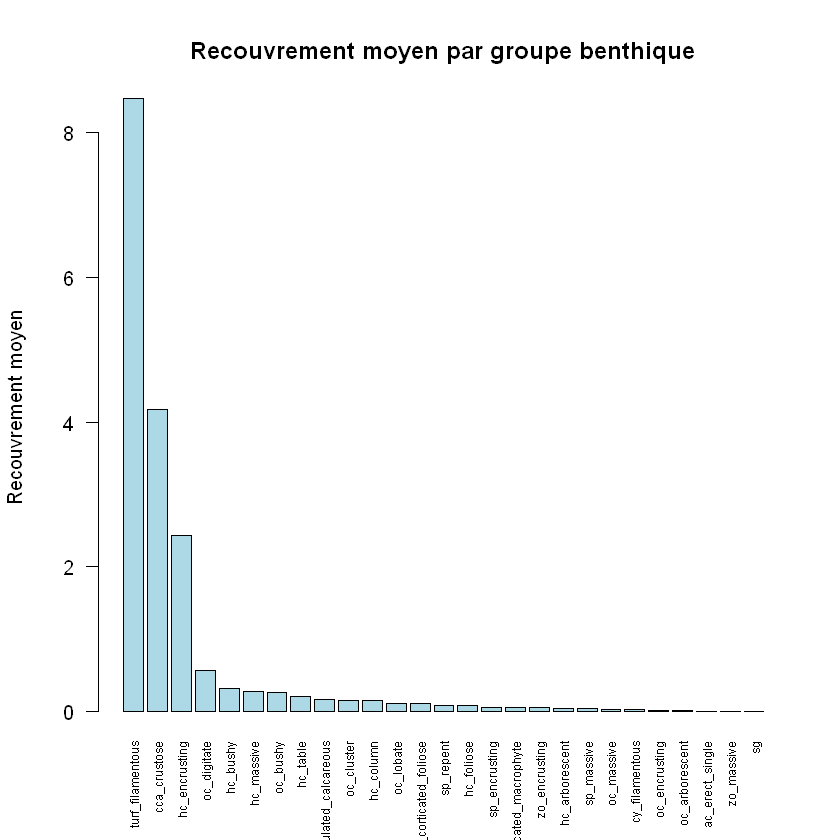

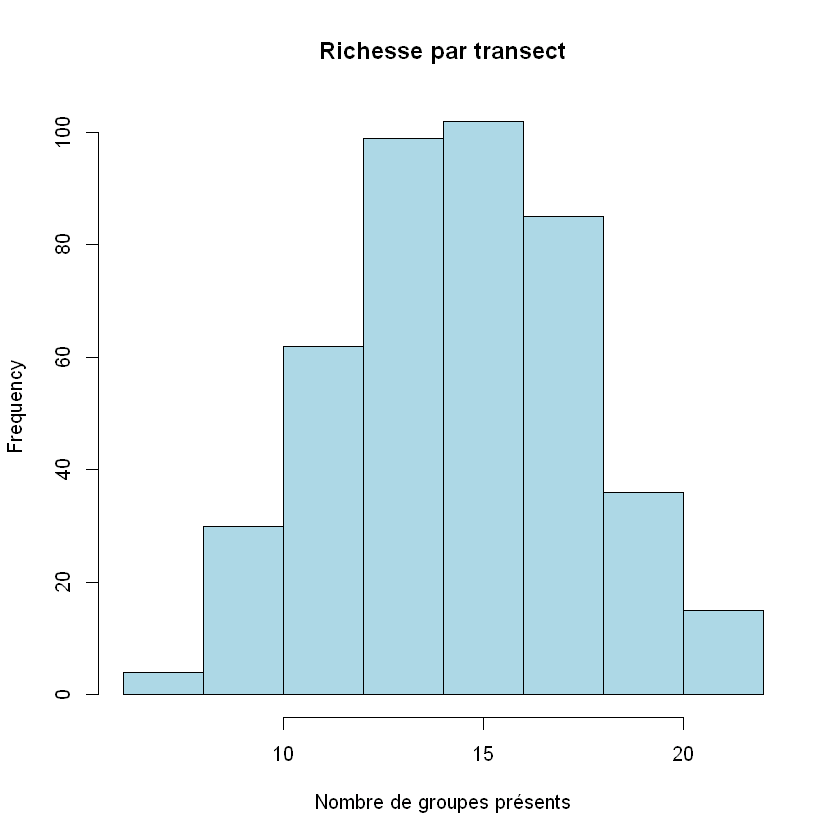

In [5]:
moy <- sort(colMeans(benthic), decreasing = TRUE)
round(head(moy, 10), 3)

freq <- sort(colSums(benthic > 0), decreasing = TRUE)      # présence dans combien de transects
mean(benthic == 0)                                         # part de zéros dans le tableau

dominant <- colnames(benthic)[apply(benthic, 1, which.max)]
sort(table(dominant), decreasing = TRUE)                   # groupe dominant par transect

write.csv(round(stat.desc(benthic), 3), file.path(tab_dir, "benthic_stat_desc.csv"))

show_save("01_benthic_mean_cover.png", {
  barplot(moy, las = 2, cex.names = 0.6, col = "lightblue",
          ylab = "Recouvrement moyen", main = "Recouvrement moyen par groupe benthique")
})
show_save("02_benthic_richness.png", {
  hist(rowSums(benthic > 0), col = "lightblue",
       xlab = "Nombre de groupes présents", main = "Richesse par transect")
})

### Décrire l'environnement

Region                     Site                    Depth 
                "factor"              "character"                "integer" 
                Latitude                Longitude                 Mean_SST 
               "numeric"                "numeric"                "numeric" 
                  SD_SST          Light_intensity            Wave_exposure 
               "numeric"                "numeric"                "numeric" 
             Wave_height               Mean_chl_a                 SD_chl_a 
               "numeric"                "numeric"                "numeric" 
                 Nitrate                  Nitrite                Phosphate 
               "numeric"                "numeric"                "numeric" 
                     DHW             DHW_recovery      Typhoon_disturbance 
               "numeric"                "integer"                "numeric" 
        Typhoon_recovery        Typhoon_frequency   Anthropogenic_land_use 
               "integer"                "integer"                "numeric" 
         Forest_land_use       Population_density         Tourist_visitors 
               "numeric"                "numeric"                "numeric" 
Unstable_substrate_cover        Management_status 
               "numeric"                 "factor"

          Region        Site               Depth          Latitude    
 North Taiwan:110   Length:433         Min.   : 5.00   Min.   :20.59  
 Dongsha     : 59   Class :character   1st Qu.: 5.00   1st Qu.:22.05  
 East Taiwan : 55   Mode  :character   Median :10.00   Median :22.68  
 Penghu      : 50                      Mean   :12.31   Mean   :23.05  
 Xiaoliuqiu  : 45                      3rd Qu.:10.00   3rd Qu.:24.84  
 Green Island: 40                      Max.   :40.00   Max.   :25.20  
 (Other)     : 74                                                     
   Longitude        Mean_SST         SD_SST      Light_intensity  
 Min.   :116.8   Min.   :19.51   Min.   :1.688   Min.   : 0.2692  
 1st Qu.:119.6   1st Qu.:20.91   1st Qu.:1.755   1st Qu.: 5.8722  
 Median :121.4   Median :23.64   Median :2.157   Median : 9.5025  
 Mean   :120.5   Mean   :22.88   Mean   :2.172   Mean   : 9.6188  
 3rd Qu.:121.8   3rd Qu.:24.35   3rd Qu.:2.495   3rd Qu.:13.2661  
 Max.   :122.0   Max.   :25.03


      Dongsha   East Taiwan  Green Island       Kenting  North Taiwan 
           59            55            40            39           110 
Orchid Island        Penghu    Xiaoliuqiu 
           35            50            45 


   no-take       open restricted 
        74        220        139 


 Descriptive statistics by group 
group: Dongsha
   vars  n  mean   sd median trimmed  mad   min   max range  skew kurtosis se
X1    1 59 23.59 0.03   23.6   23.59 0.06 23.53 23.64  0.11 -0.09    -0.71  0
------------------------------------------------------------ 
group: East Taiwan
   vars  n mean   sd median trimmed  mad   min  max range  skew kurtosis   se
X1    1 55   24 0.18  24.04   24.04 0.03 23.45 24.1  0.65 -2.63     5.33 0.02
------------------------------------------------------------ 
group: Green Island
   vars  n mean   sd median trimmed mad   min   max range  skew kurtosis se
X1    1 40 24.5 0.03  24.51    24.5   0 24.45 24.51  0.06 -1.11    -0.78  0
------------------------------------------------------------ 
group: Kenting
   vars  n  mean   sd median trimmed  mad   min   max range skew kurtosis se
X1    1 39 24.39 0.03  24.39   24.38 0.06 24.35 24.43  0.08 0.38    -1.29  0
------------------------------------------------------------ 
group: North Taiwan
   vars   

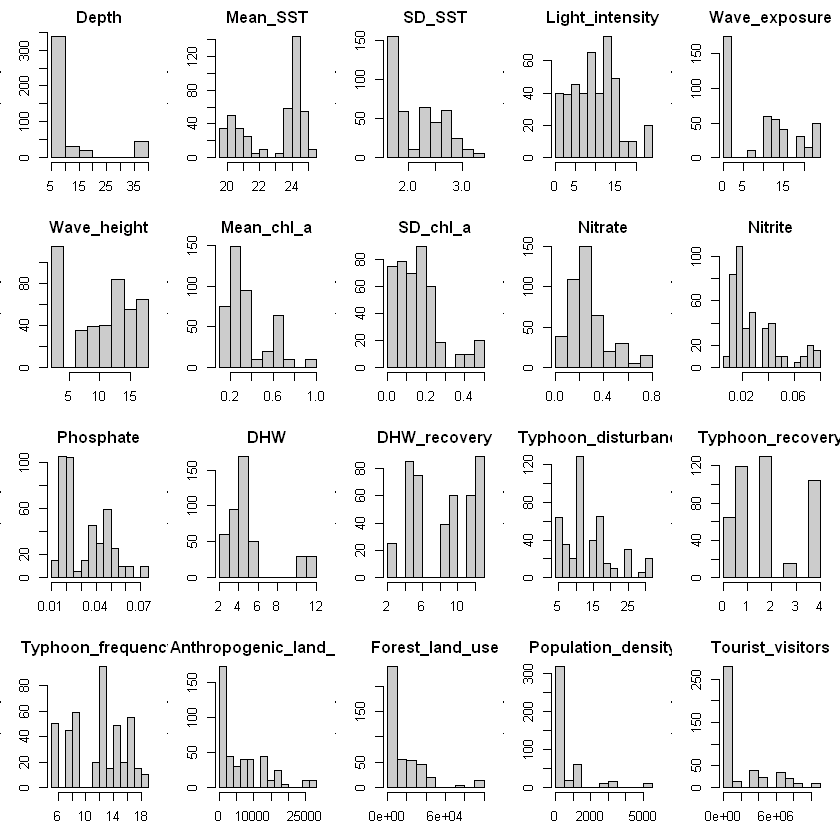

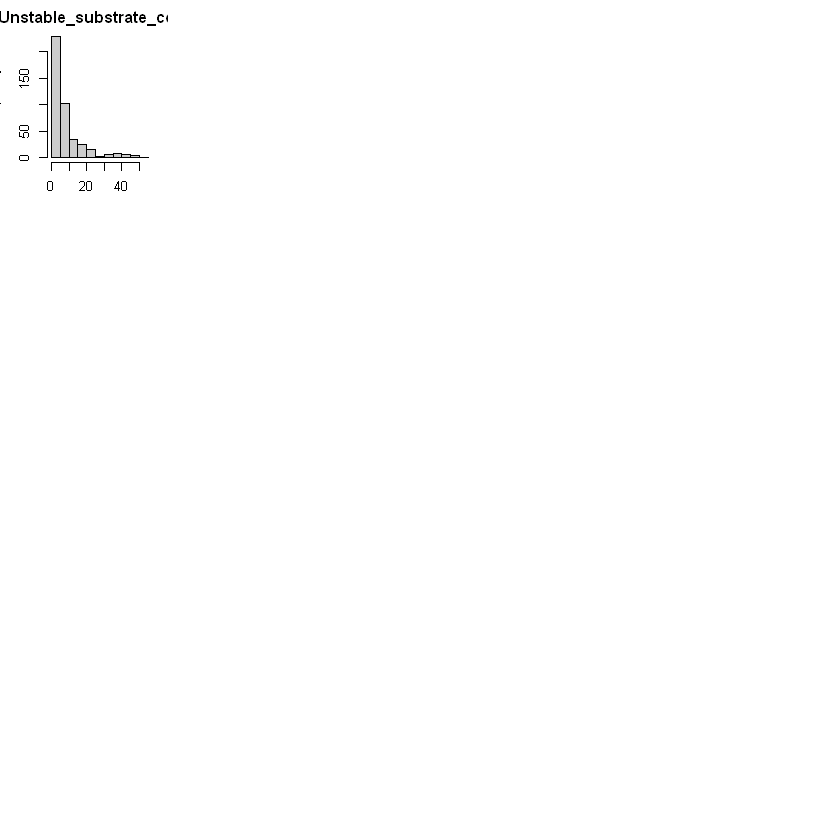

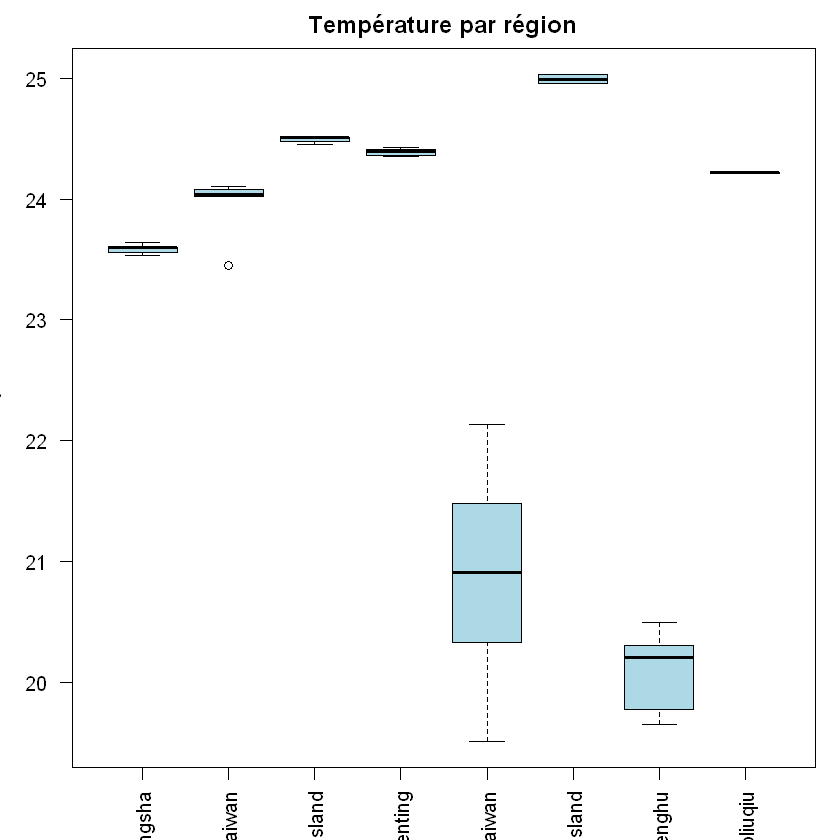

In [6]:
sapply(env, class)
summary(env)
table(env$Region)
table(env$Management_status)
describeBy(env$Mean_SST, group = env$Region)

num <- env[, sapply(env, is.numeric)]
num <- num[, !(names(num) %in% c("Latitude", "Longitude"))]   # coordonnées écartées des analyses
write.csv(round(stat.desc(num), 3), file.path(tab_dir, "env_stat_desc.csv"))

show_save("03_env_histograms.png", {
  par(mfrow = c(4, 5), mar = c(3, 3, 2, 1))
  for (v in names(num)) hist(num[[v]], main = v, xlab = "", col = "grey80")
  par(mfrow = c(1, 1))
}, w = 14, h = 10)

show_save("04_sst_by_region.png", {
  boxplot(Mean_SST ~ Region, data = env, las = 2, col = "lightblue",
          ylab = "SST moyenne", main = "Température par région")
})

### Transformer

,variable,skewness
,<chr>,<dbl>
Population_density,Population_density,2.82
Unstable_substrate_cover,Unstable_substrate_cover,2.27
Depth,Depth,2.01
Forest_land_use,Forest_land_use,1.83
DHW,DHW,1.79
Tourist_visitors,Tourist_visitors,1.34
Nitrite,Nitrite,1.24
Anthropogenic_land_use,Anthropogenic_land_use,1.19
SD_chl_a,SD_chl_a,1.18


[1] "Depth"                    "Mean_chl_a"              
 [3] "SD_chl_a"                 "Nitrate"                 
 [5] "Nitrite"                  "DHW"                     
 [7] "Anthropogenic_land_use"   "Forest_land_use"         
 [9] "Population_density"       "Tourist_visitors"        
[11] "Unstable_substrate_cover"

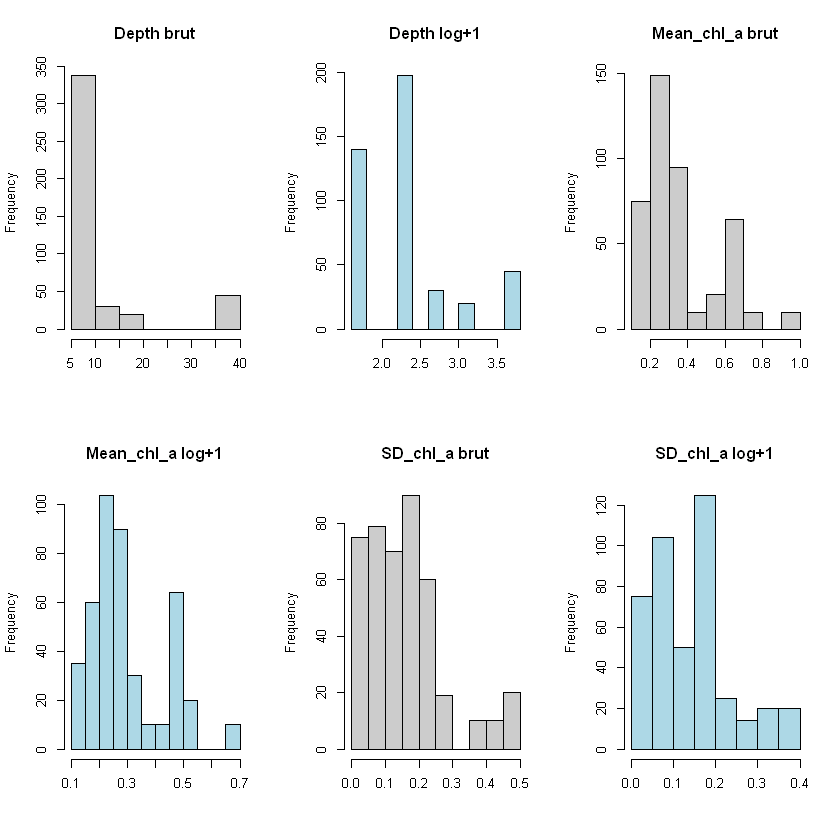

In [7]:
sk <- sapply(num, skew)
sk_tab <- data.frame(variable = names(sk), skewness = round(sk, 2))
sk_tab <- sk_tab[order(-abs(sk_tab$skewness)), ]
sk_tab
write.csv(sk_tab, file.path(tab_dir, "env_skewness.csv"), row.names = FALSE)

# Variables très asymétriques et positives : log(x + 1)
a_log <- names(sk)[sk > 1 & sapply(num, min) >= 0]
a_log

num_t <- num
num_t[a_log] <- log(num_t[a_log] + 1)

show_save("05_before_after_log.png", {
  par(mfrow = c(2, 3))
  for (v in head(a_log, 3)) {
    hist(num[[v]],   main = paste(v, "brut"),  xlab = "", col = "grey80")
    hist(num_t[[v]], main = paste(v, "log+1"), xlab = "", col = "lightblue")
  }
  par(mfrow = c(1, 1))
}, w = 14, h = 8)

num_std       <- scale(num_t)                      # z-scores
benthic.hel   <- decostand(benthic, method = "hellinger")

### Matrice de distances

In [12]:
set.seed(1)
idx <- sample(nrow(benthic), 40)

bc  <- vegdist(benthic[idx, ])                              # Bray-Curtis
hel <- dist(benthic.hel[idx, ])                             # Hellinger
jac <- vegdist(benthic[idx, ], method = "jac", binary = TRUE)
eu  <- dist(num_std[idx, ])                                 # environnement
gow <- daisy(cbind(num_t[idx, ], Management_status = env$Management_status[idx]),
             metric = "gower")                              # mixte, avec la catégorie

show_save("06_bray_curtis.png",  coldiss(bc,  nc = 15, diag = FALSE), w = 14, h = 7)
show_save("07_hellinger.png",    coldiss(hel, nc = 15, diag = FALSE), w = 14, h = 7)
show_save("08_jaccard.png",      coldiss(jac, nc = 15, diag = FALSE), w = 14, h = 7)
show_save("09_env_euclidean.png",coldiss(eu,  nc = 15, diag = FALSE), w = 14, h = 7)
show_save("10_env_gower.png",    coldiss(gow, nc = 15, diag = FALSE), w = 14, h = 7)

Le chargement a nécessité le package : gclus

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
"aucun package nommé 'gclus' n'est trouvé"


ERROR: Error in dmat.color(1 - D, cm.colors(nc)): impossible de trouver la fonction "dmat.color"


### COrrelations entre variables environnementales

,var1,var2,rho
,<chr>,<chr>,<dbl>
1,Mean_SST,SD_SST,-0.90
4,Mean_chl_a,SD_chl_a,0.90
5,Typhoon_recovery,Typhoon_frequency,-0.84
3,Mean_SST,SD_chl_a,-0.83
2,Mean_SST,Mean_chl_a,-0.81


Warning message in cor.test.default(env$Nitrite, env$Nitrate, method = "spearman"):
"Impossible de calculer la p-value exacte avec des ex-aequos"



	Spearman's rank correlation rho

data:  env$Nitrite and env$Nitrate
S = 5874604, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.5658213 


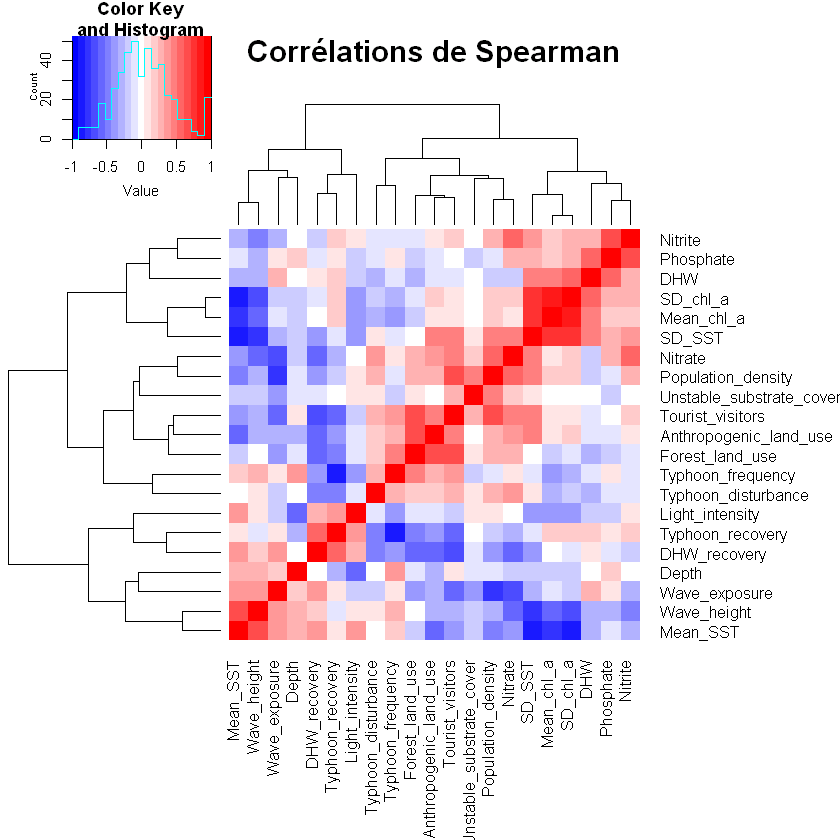

In [13]:
cm <- cor(num_t, method = "spearman")

hi <- which(abs(cm) > 0.8 & upper.tri(cm), arr.ind = TRUE)
fortes <- data.frame(var1 = rownames(cm)[hi[, 1]],
                     var2 = colnames(cm)[hi[, 2]],
                     rho  = round(cm[hi], 2))
fortes[order(-abs(fortes$rho)), ]
write.csv(fortes, file.path(tab_dir, "env_strong_correlations.csv"), row.names = FALSE)

show_save("11_env_correlations.png", {
  heatmap.2(cm, trace = "none", dendrogram = "both", symm = TRUE,
            col = colorRampPalette(c("blue", "white", "red"))(21),
            breaks = seq(-1, 1, length.out = 22),
            margins = c(10, 10), main = "Corrélations de Spearman")
}, w = 10, h = 10)

cor.test(env$Nitrite, env$Nitrate, method = "spearman")

### Relier benthos et environnement

,turf_filamentous,cca_crustose,hc_encrusting,oc_digitate,hc_bushy
Depth,-0.16,0.22,-0.03,-0.26,0.03
Mean_SST,0.03,-0.11,0.09,0.00,0.28
SD_SST,-0.07,0.14,-0.13,-0.12,-0.27
Light_intensity,0.34,-0.41,0.01,0.33,0.22
Wave_exposure,-0.36,0.13,0.19,0.07,0.08
Wave_height,-0.05,0.03,0.03,0.05,0.18
Mean_chl_a,-0.15,0.08,0.05,0.14,-0.18
SD_chl_a,-0.08,0.09,0.06,0.07,-0.25
Nitrate,0.31,-0.02,-0.18,-0.23,-0.16
Nitrite,0.18,0.14,-0.24,-0.07,-0.31


Warning message in image.default(z = matrix(z, ncol = 1), col = col, breaks = tmpbreaks, :
"'breaks' non triés fournis et seront triès avant usage"
Warning message in image.default(z = matrix(z, ncol = 1), col = col, breaks = tmpbreaks, :
"'breaks' non triés fournis et seront triès avant usage"


Wave_exposure        Typhoon_frequency                      DHW 
                   -0.36                    -0.23                    -0.21 
                   Depth               Mean_chl_a                 SD_chl_a 
                   -0.16                    -0.15                    -0.08 
                  SD_SST              Wave_height             DHW_recovery 
                   -0.07                    -0.05                    -0.05 
  Anthropogenic_land_use                Phosphate          Forest_land_use 
                   -0.04                    -0.02                     0.01 
        Tourist_visitors                 Mean_SST         Typhoon_recovery 
                    0.02                     0.03                     0.15 
Unstable_substrate_cover                  Nitrite      Typhoon_disturbance 
                    0.17                     0.18                     0.21 
                 Nitrate       Population_density          Light_intensity 
                    0.31                     0.31                     0.34

[1] "Wave_exposure"

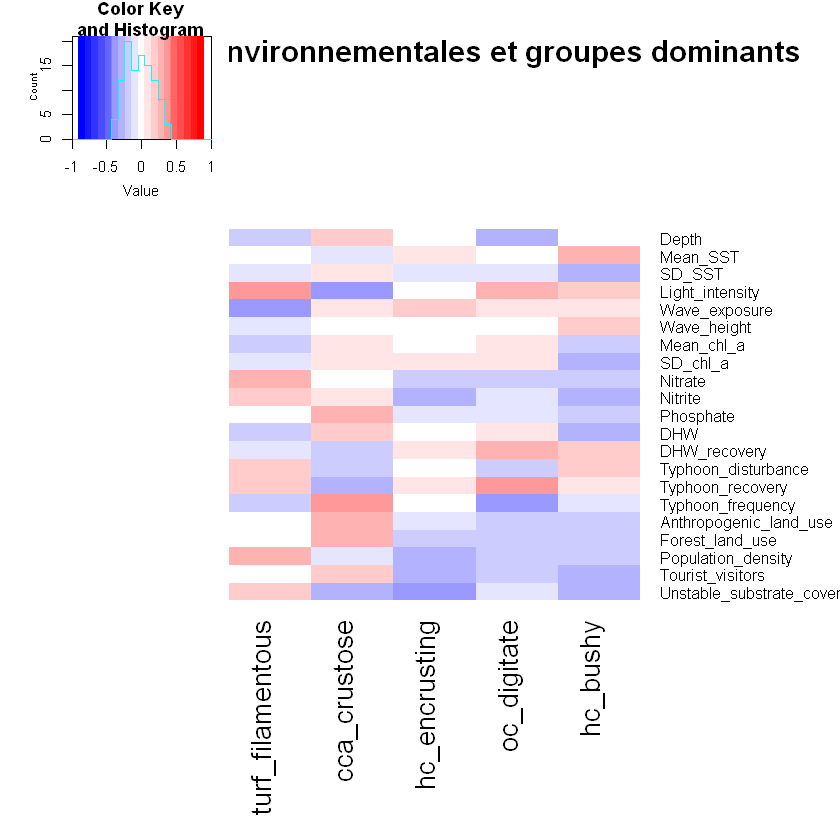


Call:
lm(formula = benthic$turf_filamentous ~ num_t[[drv]])

Residuals:
    Min      1Q  Median      3Q     Max 
-6.3914 -2.3860 -0.0119  2.1389  7.5268 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9.58974    0.20688  46.354  < 2e-16 ***
num_t[[drv]] -0.11785    0.01655  -7.123 4.47e-12 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.806 on 431 degrees of freedom
Multiple R-squared:  0.1053,	Adjusted R-squared:  0.1032 
F-statistic: 50.73 on 1 and 431 DF,  p-value: 4.472e-12


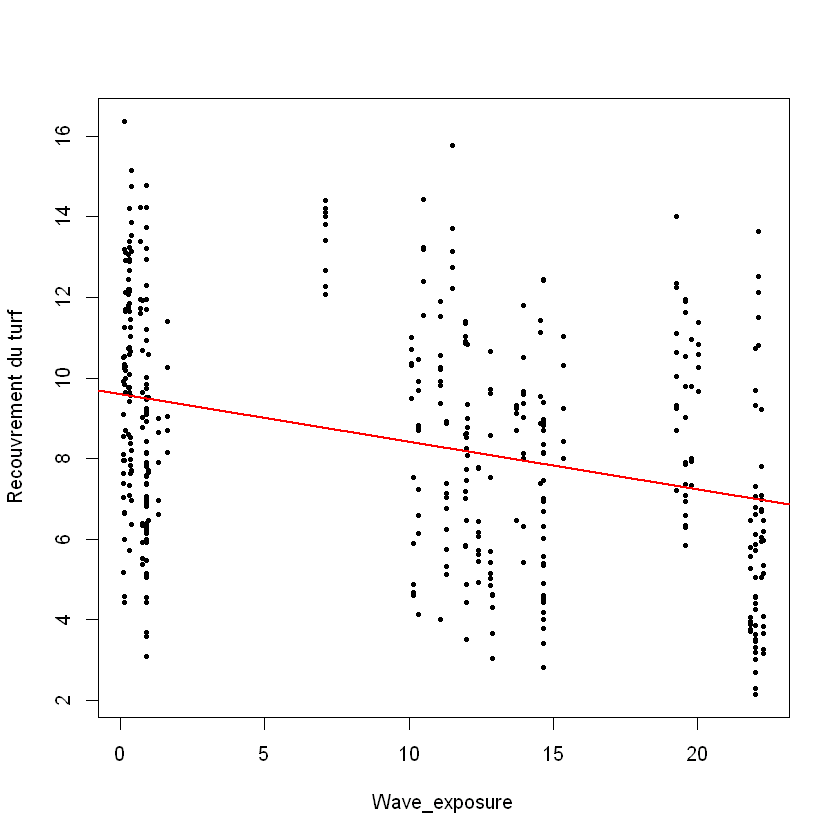

In [14]:
top   <- names(moy)[1:5]
cc    <- cor(num_t, benthic[, top], method = "spearman")
round(cc, 2)
write.csv(round(cc, 3), file.path(tab_dir, "env_vs_top_benthic.csv"))

show_save("12_env_vs_benthic.png", {
  heatmap.2(cc, trace = "none", dendrogram = "none", Rowv = FALSE, Colv = FALSE,
            col = colorRampPalette(c("blue", "white", "red"))(21),
            breaks = seq(-1, 1, length.out = 22),
            margins = c(12, 10), main = "Variables environnementales et groupes dominants")
}, w = 9, h = 10)

sort(round(cc[, "turf_filamentous"], 2))            # drivers les plus liés au turf
drv <- names(which.max(abs(cc[, "turf_filamentous"])))
drv

show_save("13_turf_vs_driver.png", {
  plot(num_t[[drv]], benthic$turf_filamentous, pch = 19, cex = 0.5,
       xlab = drv, ylab = "Recouvrement du turf")
  mod <- lm(benthic$turf_filamentous ~ num_t[[drv]])
  abline(mod, col = "red", lwd = 2)
})
summary(lm(benthic$turf_filamentous ~ num_t[[drv]]))

### Carte des transects

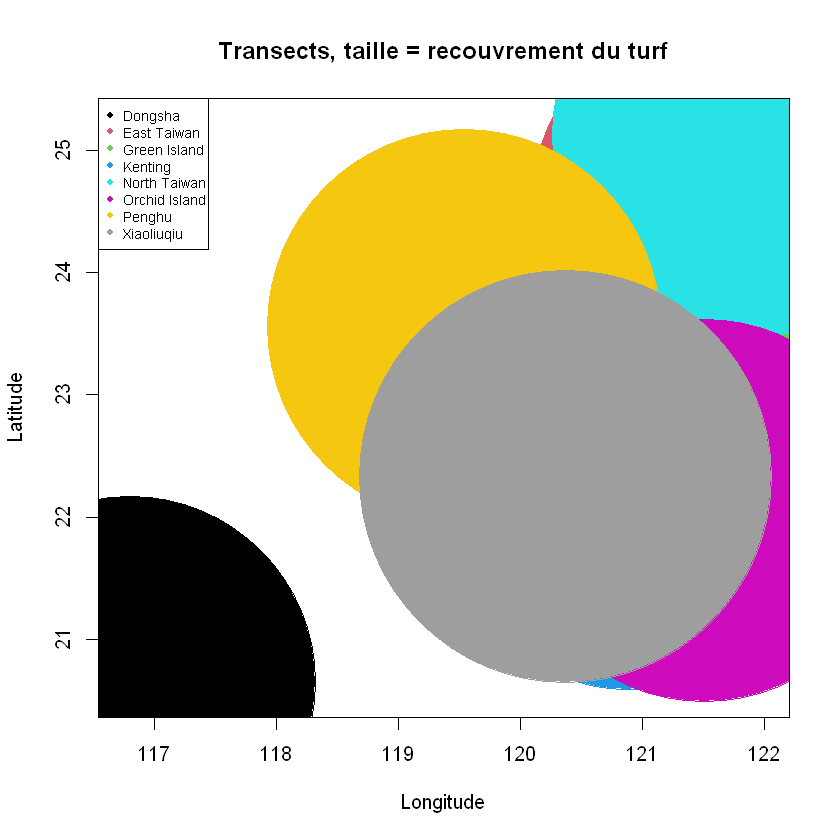

In [15]:
show_save("14_map_turf.png", {
  plot(env$Longitude, env$Latitude, asp = 1, pch = 19,
       col = as.integer(env$Region), cex = 0.5 + benthic$turf_filamentous * 3,
       xlab = "Longitude", ylab = "Latitude", main = "Transects, taille = recouvrement du turf")
  legend("topleft", legend = levels(env$Region), col = seq_along(levels(env$Region)),
         pch = 19, cex = 0.7)
})

### Groupes de communautés (k-means)

In [16]:
set.seed(1)
km <- kmeans(benthic.hel, centers = 5, nstart = 25)

table(km$cluster)
table(km$cluster, env$Region)
round(aggregate(benthic[, top], list(groupe = km$cluster), mean), 3)


  1   2   3   4   5 
128  27  23 155 100 

   
    Dongsha East Taiwan Green Island Kenting North Taiwan Orchid Island Penghu
  1      33          15            8       6           18            24     22
  2      14           8            0       4            0             1      0
  3       0           0           23       0            0             0      0
  4       6          20            6      14           29             9     28
  5       6          12            3      15           63             1      0
   
    Xiaoliuqiu
  1          2
  2          0
  3          0
  4         43
  5          0

groupe,turf_filamentous,cca_crustose,hc_encrusting,oc_digitate,hc_bushy
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,7.441,3.331,4.182,0.393,0.611
2,5.192,4.163,1.976,5.805,0.202
3,5.911,2.617,2.322,0.014,0.631
4,11.242,2.802,1.554,0.203,0.201
5,6.974,7.708,1.718,0.062,0.071
